In [ ]:
# !conda install scipy --update-deps

In [6]:
import pandas as pd
import numpy as np
import os
import pyodbc
from datetime import datetime, date
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

C:\Users\Namrata.Paikekar\AppData\Local\anaconda3\envs\newenv\Lib\site-packages\statsmodels\tools\tools.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.2)
  import scipy.linalg


In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [6]:
# SQL connection
Driver= 'SQL Server'
Server = r'MDIanalyticDB'
Database = 'Masters'
UID = 'mdianalytics'
PWD= 'mdianalytics@123'
Database_Connection = f'mssql://{UID}:{PWD}@{Server}/{Database}?driver={Driver}'
    
cnxn = pyodbc.connect(driver='{SQL Server}', host=Server, database=Database,
                     user=UID, password=PWD)

In [3]:
query = """
SELECT *
FROM [Stats].[dbo].[InsParamSummary_BOB_Only_M]
WHERE Client_Type = 'non-corporate'
  AND IC_Name LIKE '%national insurance company limited%'
"""
data = pd.read_sql_query(query, cnxn)

NameError: name 'pd' is not defined

In [4]:
df = data.copy(deep=True)

NameError: name 'data' is not defined

In [1]:
df.head(3)

NameError: name 'df' is not defined

In [ ]:
df.shape

In [2]:
df.dtypes

NameError: name 'df' is not defined

In [9]:
df['Report_Date'] = pd.to_datetime(df['Report_Date'])

In [10]:
# checking number of unique values in all categorical features

for col in df.select_dtypes(include='object'):
    print(f"No of unique values in {col} = {df[col].str.lower().str.strip().nunique()}")

No of unique values in IC_Name = 1
No of unique values in RO_Name = 21
No of unique values in RO_Code = 412
No of unique values in DO_Name = 171
No of unique values in DO_Code = 189
No of unique values in UO_Name = 398
No of unique values in UO_Code = 412
No of unique values in Servicing_Branch = 23
No of unique values in Client_Type = 1
No of unique values in PolicySubType = 24


In [11]:
# lowercasing categorical features and removing white spaces inbetween to avoid duplicacy in categories and data standardization

df['IC_Name'] = df['IC_Name'].str.lower().str.strip()
df['RO_Code'] = df['RO_Code'].str.lower().str.strip()
df['RO_Name'] = df['RO_Name'].str.lower().str.strip()
df['DO_Code'] = df['DO_Code'].str.lower().str.strip()
df['DO_Name'] = df['DO_Name'].str.lower().str.strip()
df['UO_Code'] = df['UO_Code'].str.lower().str.strip()
df['UO_Name'] = df['UO_Name'].str.lower().str.strip()
df['Servicing_Branch'] = df['Servicing_Branch'].str.lower().str.strip()
df['Client_Type'] = df['Client_Type'].str.lower().str.strip()
df['PolicySubType'] = df['PolicySubType'].str.lower().str.strip()

In [12]:
df.columns

Index(['Report_Date', 'IC_Name', 'RO_Name', 'RO_Code', 'DO_Name', 'DO_Code',
       'UO_Name', 'UO_Code', 'Servicing_Branch', 'Client_Type',
       'PolicySubType', 'ActiveLives', 'No_Of_Policies', 'Inception_Premium',
       'endors_premium', 'PolicyRunday', 'Beg_OS_Cashless_Claims',
       'Beg_OS_NonCashless_Claims', 'Beg_OS_Cashless_LodgeAmt',
       'Beg_OS_NonCashless_LodgeAmt', 'Beg_OS_Cashless_LiabAmt',
       'Beg_OS_NonCashless_LiabAmt', 'Paid_Cashless_Claims',
       'Paid_NonCashless_Claims', 'Paid_Cashless_LodgeAmt',
       'Paid_NonCashless_LodgeAmt', 'Paid_Cashless_LiabAmt',
       'Paid_NonCashless_LiabAmt', 'CRS_Cashless_Claims',
       'CRS_NonCashless_Claims', 'CRS_Cashless_LodgeAmt',
       'CRS_NonCashless_LodgeAmt', 'CRS_Cashless_LiabAmt',
       'CRS_NonCashless_LiabAmt', 'End_OS_Cashless_Claims',
       'End_OS_NonCashless_Claims', 'End_OS_Cashless_LodgeAmt',
       'End_OS_NonCashless_LodgeAmt', 'End_OS_Cashless_LiabAmt',
       'End_OS_NonCashless_LiabAmt'],
 

In [13]:
df['Client_Type'].value_counts()

Client_Type
non-corporate    67797
Name: count, dtype: int64

In [14]:
df.isnull().sum()

Report_Date                    0
IC_Name                        0
RO_Name                        0
RO_Code                        0
DO_Name                        0
DO_Code                        0
UO_Name                        0
UO_Code                        0
Servicing_Branch               0
Client_Type                    0
PolicySubType                  0
ActiveLives                    0
No_Of_Policies                 0
Inception_Premium              0
endors_premium                 0
PolicyRunday                   0
Beg_OS_Cashless_Claims         0
Beg_OS_NonCashless_Claims      0
Beg_OS_Cashless_LodgeAmt       0
Beg_OS_NonCashless_LodgeAmt    0
Beg_OS_Cashless_LiabAmt        0
Beg_OS_NonCashless_LiabAmt     0
Paid_Cashless_Claims           0
Paid_NonCashless_Claims        0
Paid_Cashless_LodgeAmt         0
Paid_NonCashless_LodgeAmt      0
Paid_Cashless_LiabAmt          0
Paid_NonCashless_LiabAmt       0
CRS_Cashless_Claims            0
CRS_NonCashless_Claims         0
CRS_Cashle

In [15]:
#calculate total_crs_claims
df['Total_crs_claims'] = df['CRS_NonCashless_Claims']+df['CRS_Cashless_Claims']
df['Total_paid_claims'] = df['Paid_NonCashless_Claims']+df['Paid_Cashless_Claims']
df['Total_End_OS_claims'] = df['End_OS_NonCashless_Claims']+df['End_OS_Cashless_Claims']
df['Total_Beg_OS_claims'] = df['Beg_OS_NonCashless_Claims']+df['Beg_OS_Cashless_Claims']
df['Total_Rep_Claims'] = df['Total_paid_claims']+df['Total_crs_claims']+df['Total_End_OS_claims']-df['Total_Beg_OS_claims']
df['Settled_Claims'] = df['Total_crs_claims']+df['Total_paid_claims']

In [16]:
# replace all values of total_beg_os_claims > than sum of paid, crs and end os claims with 0.
df.loc[df['Total_Beg_OS_claims']>(df['Total_crs_claims']+df['Total_paid_claims']+df['Total_End_OS_claims']),'Total_Beg_OS_claims']=0

In [17]:
df['Settlement_Ratio']=(df['Settled_Claims']/df['Total_Rep_Claims'])*100

In [18]:
#set all Settlement_Ratio < 0 to 0 and >100 to 100

df.loc[df['Settlement_Ratio'] < 0, 'Settlement_Ratio'] = 0
df.loc[df['Settlement_Ratio'] > 100, 'Settlement_Ratio'] = 100

In [19]:
df.head(3)

,Report_Date,IC_Name,RO_Name,RO_Code,DO_Name,DO_Code,UO_Name,UO_Code,Servicing_Branch,Client_Type,PolicySubType,ActiveLives,No_Of_Policies,Inception_Premium,endors_premium,PolicyRunday,Beg_OS_Cashless_Claims,Beg_OS_NonCashless_Claims,Beg_OS_Cashless_LodgeAmt,Beg_OS_NonCashless_LodgeAmt,Beg_OS_Cashless_LiabAmt,Beg_OS_NonCashless_LiabAmt,Paid_Cashless_Claims,Paid_NonCashless_Claims,Paid_Cashless_LodgeAmt,Paid_NonCashless_LodgeAmt,Paid_Cashless_LiabAmt,Paid_NonCashless_LiabAmt,CRS_Cashless_Claims,CRS_NonCashless_Claims,CRS_Cashless_LodgeAmt,CRS_NonCashless_LodgeAmt,CRS_Cashless_LiabAmt,CRS_NonCashless_LiabAmt,End_OS_Cashless_Claims,End_OS_NonCashless_Claims,End_OS_Cashless_LodgeAmt,End_OS_NonCashless_LodgeAmt,End_OS_Cashless_LiabAmt,End_OS_NonCashless_LiabAmt,Total_crs_claims,Total_paid_claims,Total_End_OS_claims,Total_Beg_OS_claims,Total_Rep_Claims,Settled_Claims,Settlement_Ratio
0,2019-04-01,national insurance company limited,ahmedabad ro,300500,junagadh do,3005,junagadh do,300500,ahmedabad,non-corporate,national mediclaim,22,7,56869.0,0.0,126,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,189000.0,470601.0,126000.0,375348.0,0.0,1.0,0.0,63756.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,0.0,6.0,6.0,100.0
1,2019-04-01,national insurance company limited,ahmedabad ro,300500,junagadh do,3005,junagadh do,300500,ahmedabad,non-corporate,national parivar mediclaim,2,1,41368.0,0.0,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,33493.0,0.0,29697.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,100.0
2,2019-04-01,national insurance company limited,ahmedabad ro,300500,junagadh do,3005,junagadh do,300500,ahmedabad,non-corporate,parivar mediclaim,22,4,39688.0,0.0,38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,17298.0,0.0,16748.0,0.0,0.0,0.0,133625.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0,2.0,100.0


In [20]:
#check null values in df 
df.isnull().sum()

Report_Date                        0
IC_Name                            0
RO_Name                            0
RO_Code                            0
DO_Name                            0
DO_Code                            0
UO_Name                            0
UO_Code                            0
Servicing_Branch                   0
Client_Type                        0
PolicySubType                      0
ActiveLives                        0
No_Of_Policies                     0
Inception_Premium                  0
endors_premium                     0
PolicyRunday                       0
Beg_OS_Cashless_Claims             0
Beg_OS_NonCashless_Claims          0
Beg_OS_Cashless_LodgeAmt           0
Beg_OS_NonCashless_LodgeAmt        0
Beg_OS_Cashless_LiabAmt            0
Beg_OS_NonCashless_LiabAmt         0
Paid_Cashless_Claims               0
Paid_NonCashless_Claims            0
Paid_Cashless_LodgeAmt             0
Paid_NonCashless_LodgeAmt          0
Paid_Cashless_LiabAmt              0
P

In [32]:
#so as per data above fetched we can observe that no claims reported. so no of settled claims =0 and 
# dataframe have Nan value for all such records but in business perspective settlement should be 100%. 
# impute all Nan values where reported and settled claims zero with 100.

df['Settlement_Ratio'] = df['Settlement_Ratio'].fillna(100)

In [22]:
df.isnull().sum()

Report_Date                    0
IC_Name                        0
RO_Name                        0
RO_Code                        0
DO_Name                        0
DO_Code                        0
UO_Name                        0
UO_Code                        0
Servicing_Branch               0
Client_Type                    0
PolicySubType                  0
ActiveLives                    0
No_Of_Policies                 0
Inception_Premium              0
endors_premium                 0
PolicyRunday                   0
Beg_OS_Cashless_Claims         0
Beg_OS_NonCashless_Claims      0
Beg_OS_Cashless_LodgeAmt       0
Beg_OS_NonCashless_LodgeAmt    0
Beg_OS_Cashless_LiabAmt        0
Beg_OS_NonCashless_LiabAmt     0
Paid_Cashless_Claims           0
Paid_NonCashless_Claims        0
Paid_Cashless_LodgeAmt         0
Paid_NonCashless_LodgeAmt      0
Paid_Cashless_LiabAmt          0
Paid_NonCashless_LiabAmt       0
CRS_Cashless_Claims            0
CRS_NonCashless_Claims         0
CRS_Cashle

### UO Codes Analysis

In [23]:
UO_SR_df = df[['Report_Date','UO_Name','UO_Code','Total_crs_claims','Total_paid_claims','Total_End_OS_claims',
'Total_Beg_OS_claims','Total_Rep_Claims','Settled_Claims','Settlement_Ratio']]

In [24]:
agg_df = UO_SR_df.groupby(['Report_Date', 'UO_Name', 'UO_Code'], as_index=False)['Settlement_Ratio'].mean()

In [25]:
agg_df.shape

(18247, 4)

In [26]:
agg_df.set_index('Report_Date', inplace=True)

In [27]:
agg_df.head()

,UO_Name,UO_Code,Settlement_Ratio
Report_Date,,,
2019-04-01,,610800,100.0
2019-04-01,adilabad-bo,551301,100.0
2019-04-01,adoni branch,552301,100.0
2019-04-01,agra branch,462301,100.0
2019-04-01,agra division i,461400,100.0


In [28]:
# most frequent top 10 uo_names 
top_10_uo_codes = UO_SR_df['UO_Code'].value_counts(ascending=False).head(10).index.tolist()
print(top_10_uo_codes)

['150100', '361900', '100200', '271500', '240800', '106006', '360701', '240100', '311500', '280400']


In [30]:
# Create a dictionary to hold the 10 DataFrames
uo_dfs = {}

# Loop through each top UO_Name and create a separate DataFrame
for code in top_10_uo_codes:
    uo_dfs[code] = UO_SR_df[UO_SR_df['UO_Code'] == code].copy()

## UO_Code 150100 Analysis

In [31]:
agg_uo_150100=uo_dfs['150100'].groupby(['Report_Date'], as_index=False)['Settlement_Ratio'].mean()
agg_uo_150100

,Report_Date,Settlement_Ratio
0,2019-04-01,100.000000
1,2019-05-01,100.000000
2,2019-06-01,100.000000
3,2019-07-01,100.000000
4,2019-08-01,100.000000
5,2019-09-01,100.000000
6,2019-10-01,100.000000
7,2019-11-01,100.000000
8,2019-12-01,100.000000
9,2020-01-01,100.000000


In [32]:
# Set the Report_Date as index
agg_uo_150100.set_index('Report_Date', inplace=True)

In [33]:
agg_uo_150100.head()

,Settlement_Ratio
Report_Date,
2019-04-01,100.0
2019-05-01,100.0
2019-06-01,100.0
2019-07-01,100.0
2019-08-01,100.0


<Axes: title={'center': 'Settlement Ratio over Time for dab-3'}, xlabel='Report_Date'>

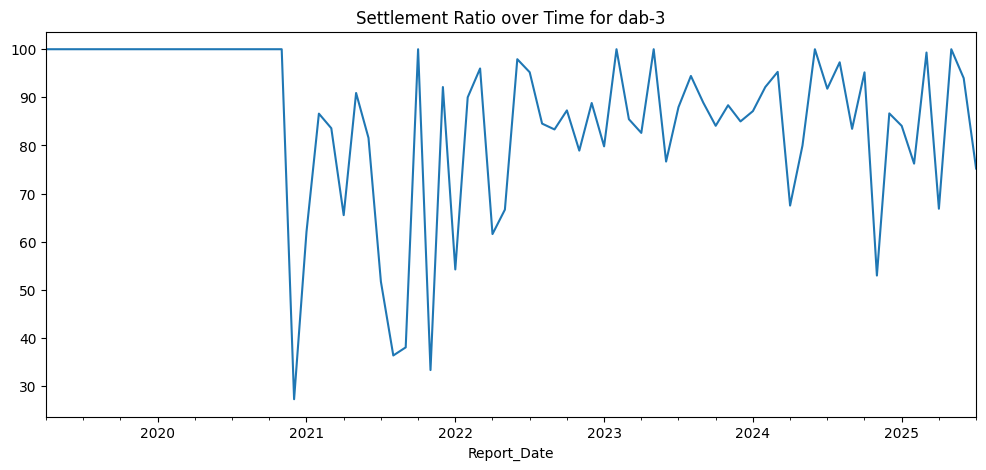

In [34]:
# Plot to visually inspect
agg_uo_150100['Settlement_Ratio'].plot(figsize=(12, 5), title='Settlement Ratio over Time for dab-3')

In [35]:
from statsmodels.tsa.stattools import adfuller
x = agg_uo_150100['Settlement_Ratio'].values
result = adfuller(x)
print('PValue is :',round(result[1],3))
print('ADF Statistics :', round(result[0],3))
for key, value in result[4].items():
    print('\t',key,":",value)

PValue is : 0.001
ADF Statistics : -4.142
	 1% : -3.5219803175527606
	 5% : -2.9014701097664504
	 10% : -2.58807215485756


In [36]:
from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries, window = 12, cutoff = 0.05):

    #Determing rolling statistics
    rolmean = timeseries.rolling(window).mean()
    rolstd = timeseries.rolling(window).std()

    #Plot rolling statistics:
    fig = plt.figure(figsize=(12, 8))
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show()
    
    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC', maxlag = 20 )
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    pvalue = dftest[1]
    if pvalue < cutoff:
        print('p-value = %.4f. The series is likely stationary.' % pvalue)
    else:
        print('p-value = %.4f. The series is likely non-stationary.' % pvalue)
    
    print(dfoutput)

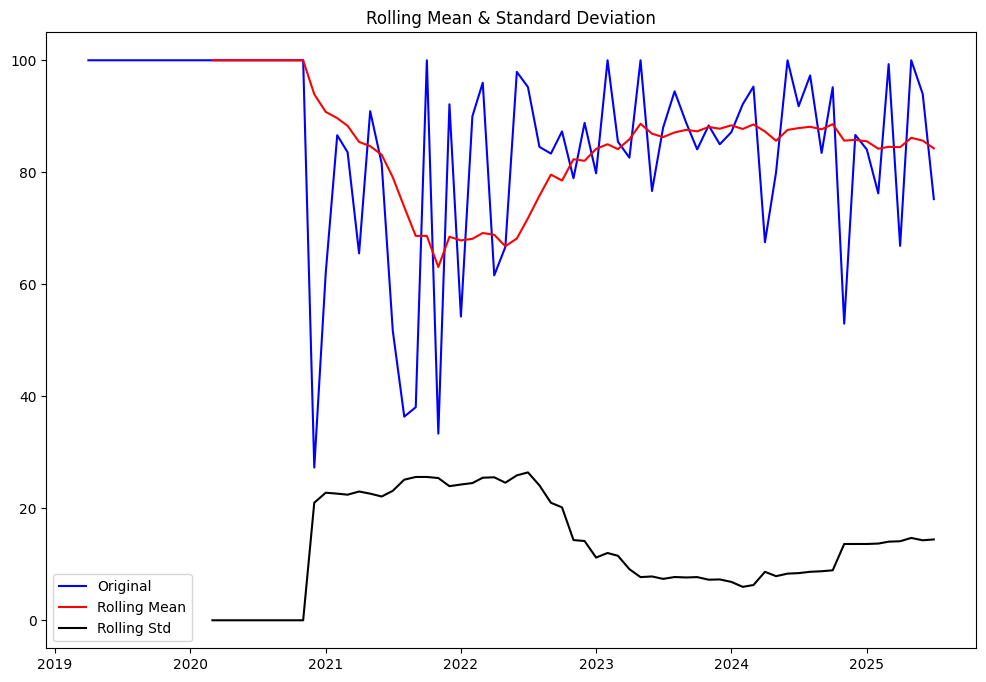

Results of Dickey-Fuller Test:
p-value = 0.0000. The series is likely stationary.
Test Statistic                -6.795321e+00
p-value                        2.308871e-09
#Lags Used                     0.000000e+00
Number of Observations Used    7.500000e+01
Critical Value (1%)           -3.520713e+00
Critical Value (5%)           -2.900925e+00
Critical Value (10%)          -2.587781e+00
dtype: float64


In [37]:
test_stationarity(agg_uo_150100)

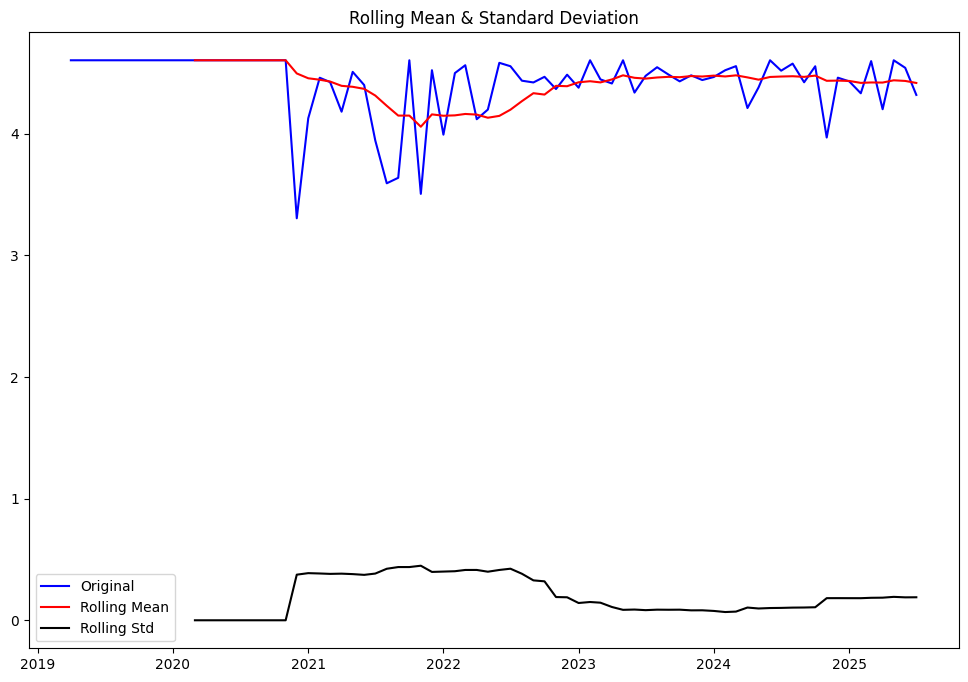

Results of Dickey-Fuller Test:
p-value = 0.0006. The series is likely stationary.
Test Statistic                 -4.225452
p-value                         0.000596
#Lags Used                      1.000000
Number of Observations Used    74.000000
Critical Value (1%)            -3.521980
Critical Value (5%)            -2.901470
Critical Value (10%)           -2.588072
dtype: float64


In [38]:
# making data stationary by log transformation
agg_uo_150100['log_outs'] = np.log(agg_uo_150100['Settlement_Ratio'])
test_stationarity(agg_uo_150100['log_outs'])

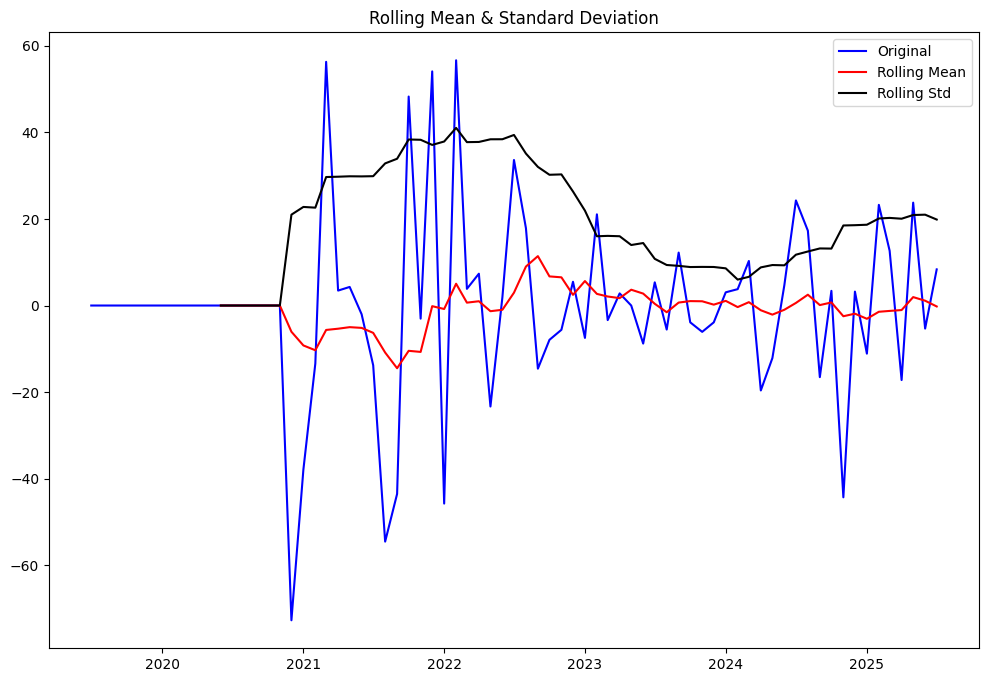

Results of Dickey-Fuller Test:
p-value = 0.1243. The series is likely non-stationary.
Test Statistic                 -2.464812
p-value                         0.124272
#Lags Used                      7.000000
Number of Observations Used    65.000000
Critical Value (1%)            -3.535217
Critical Value (5%)            -2.907154
Critical Value (10%)           -2.591103
dtype: float64


In [39]:
# making data stationary by Differencing
agg_uo_150100['Outs_diff'] = agg_uo_150100['Settlement_Ratio'] - agg_uo_150100['Settlement_Ratio'].shift(3)
test_stationarity(agg_uo_150100['Outs_diff'].dropna())

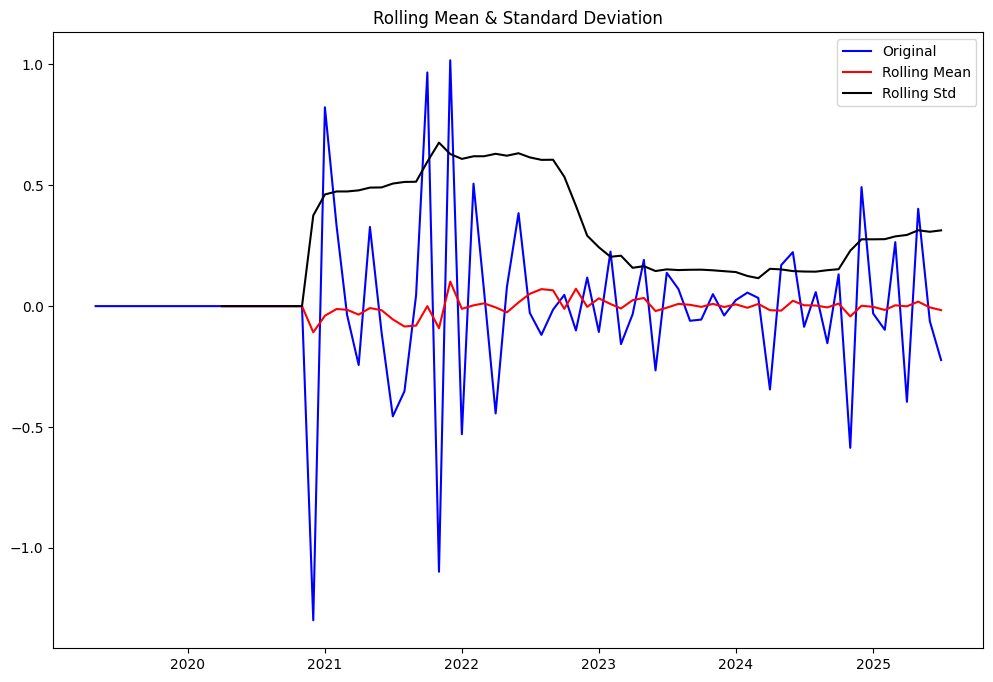

Results of Dickey-Fuller Test:
p-value = 0.0173. The series is likely stationary.
Test Statistic                 -3.249195
p-value                         0.017308
#Lags Used                      8.000000
Number of Observations Used    66.000000
Critical Value (1%)            -3.533560
Critical Value (5%)            -2.906444
Critical Value (10%)           -2.590724
dtype: float64


In [40]:
# Step 1: Apply first-order differencing
agg_uo_150100['out_diff1'] = agg_uo_150100['log_outs'].diff()

# Step 2: Drop NA values caused by differencing
agg_uo_150100.dropna(subset=['out_diff1'], inplace=True)

# Step 3: Test stationarity again
test_stationarity(agg_uo_150100['out_diff1'])

In [41]:
#now p-value is < 0.05 so we can say that series is now stationary

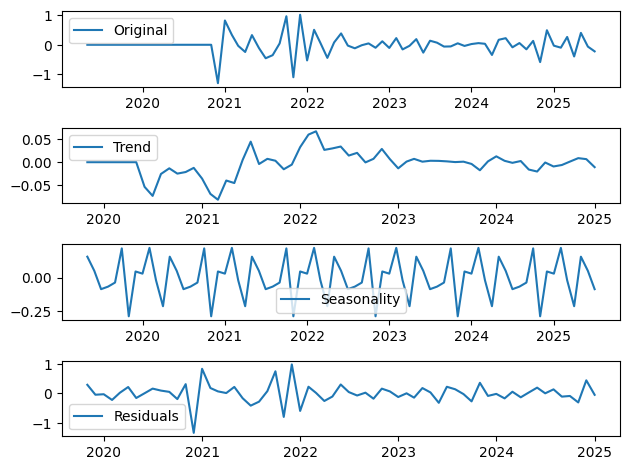

In [42]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(agg_uo_150100['out_diff1'].dropna())

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.subplot(411)
plt.plot(agg_uo_150100['out_diff1'].dropna(), label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal, label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()

### TOP 10 Most Frequent UO_Code Data Analysis for Trend, Seasonality and Residual

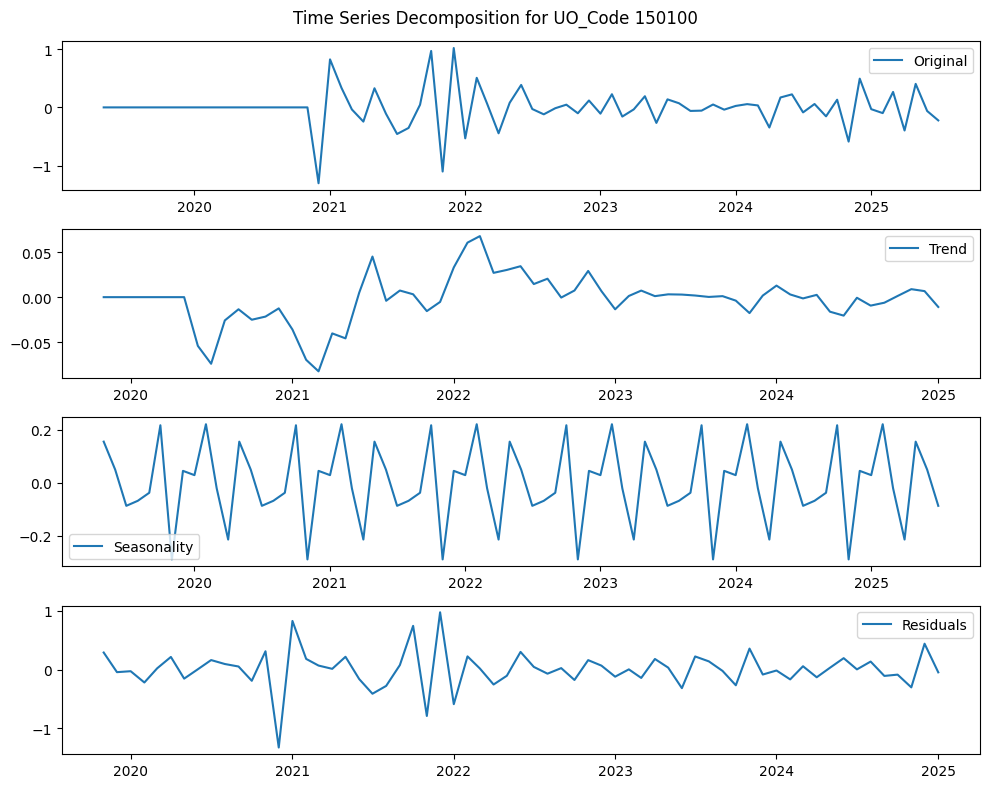

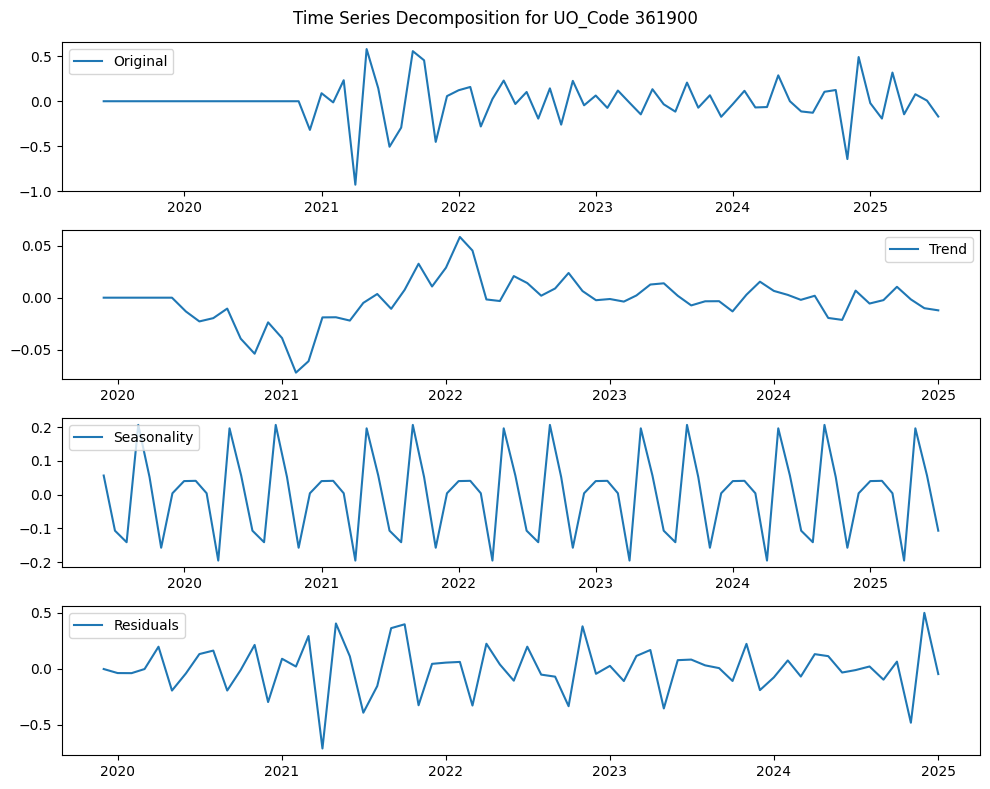

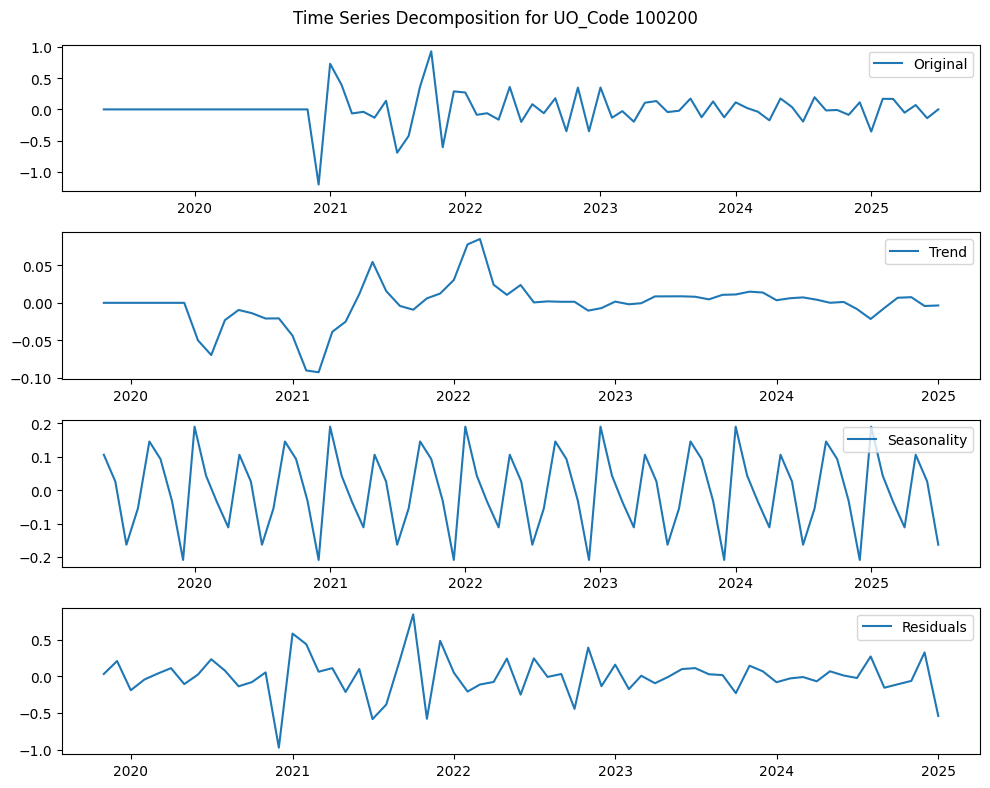

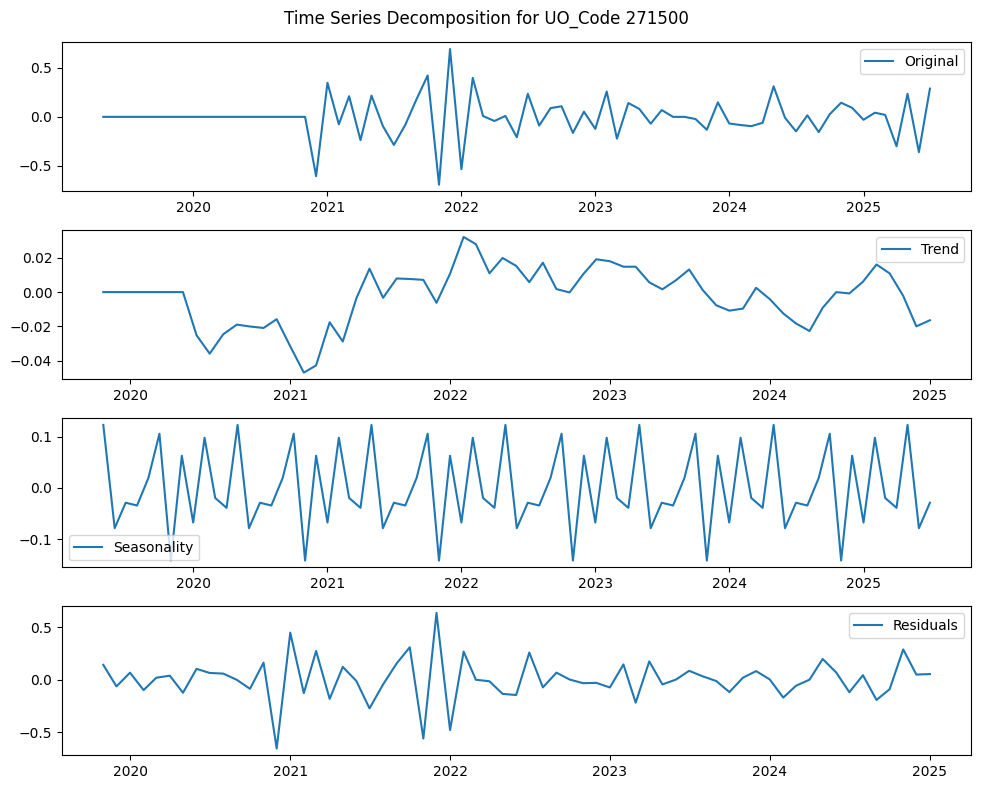

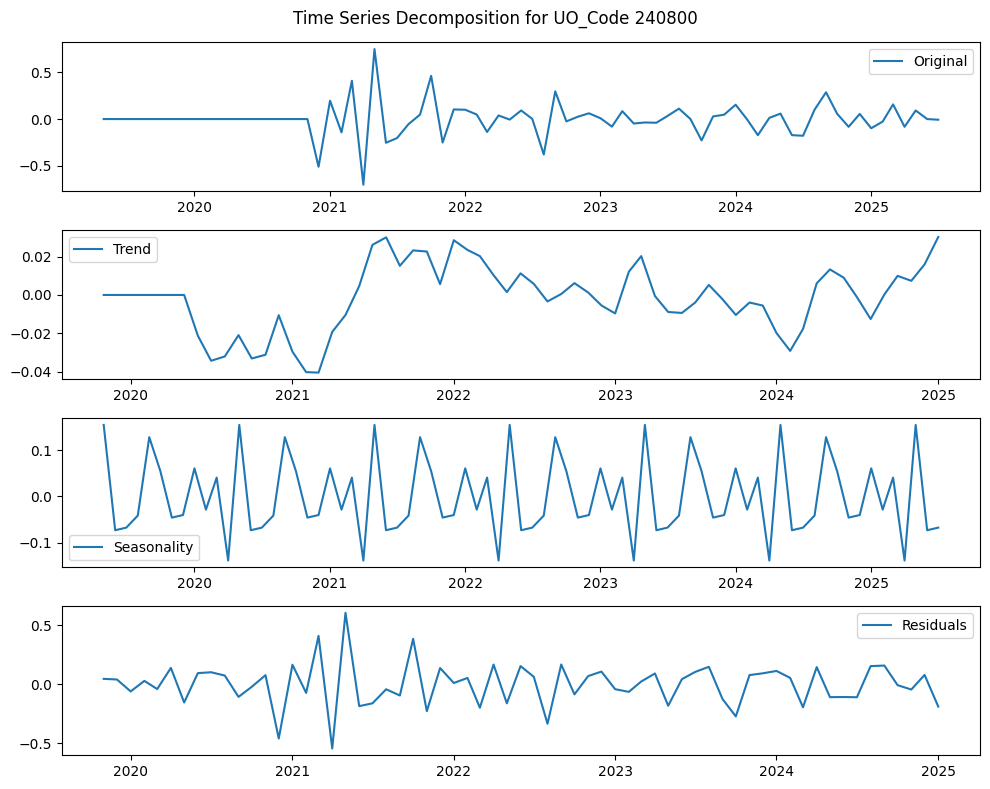

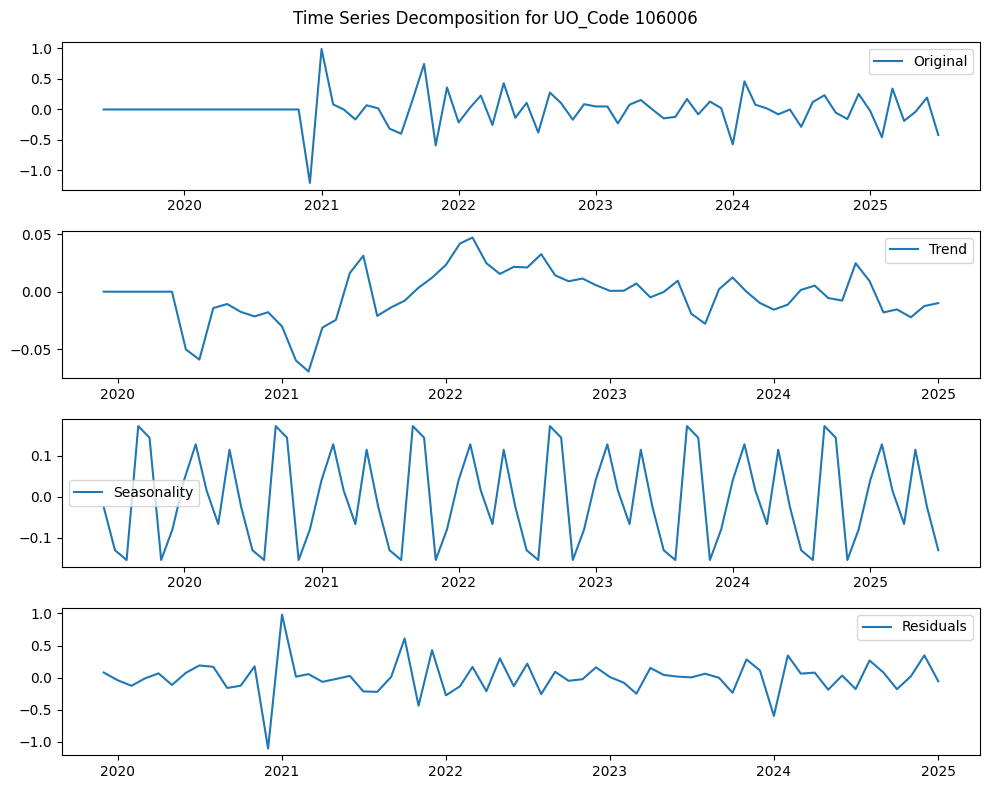

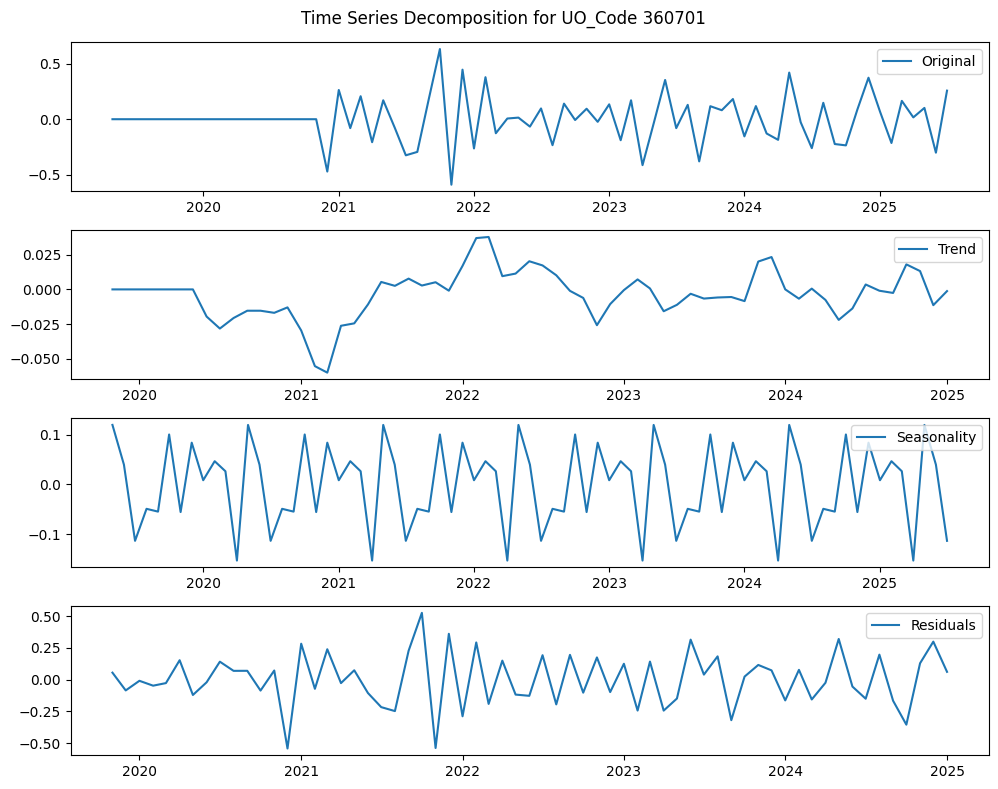

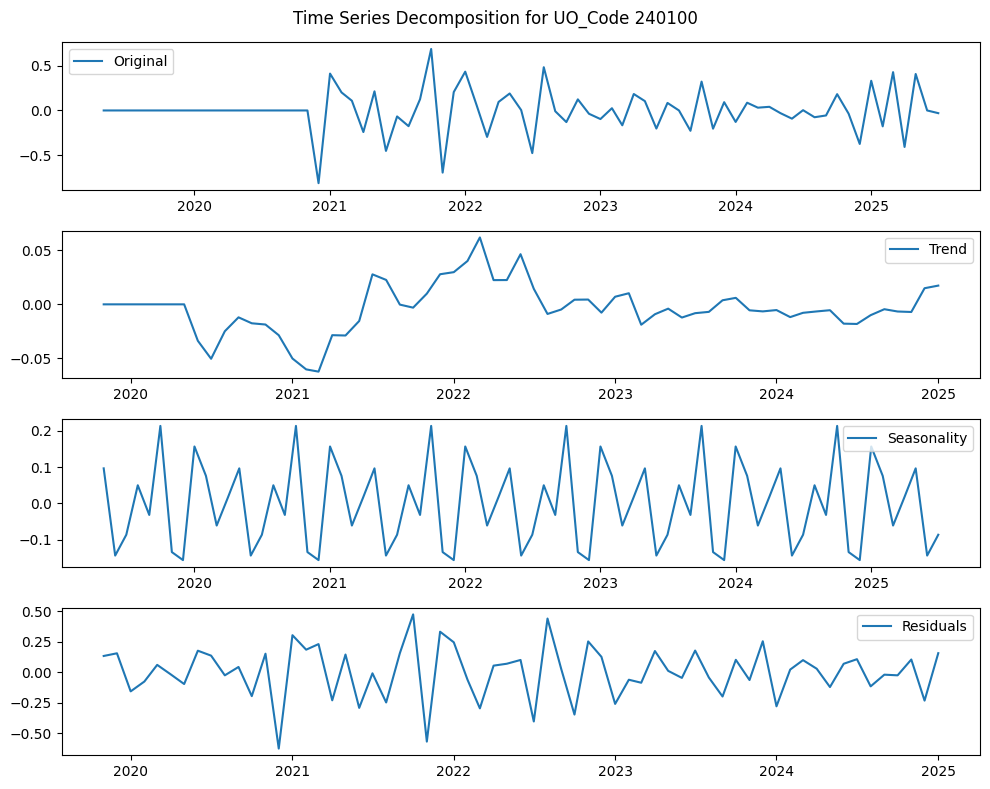

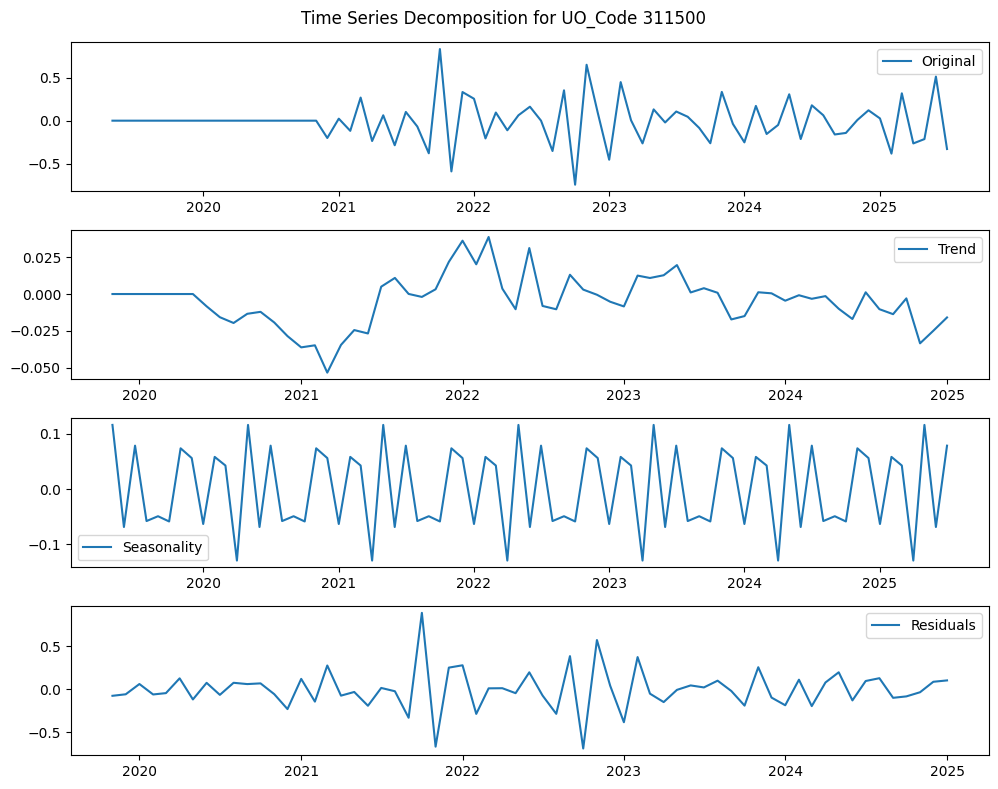

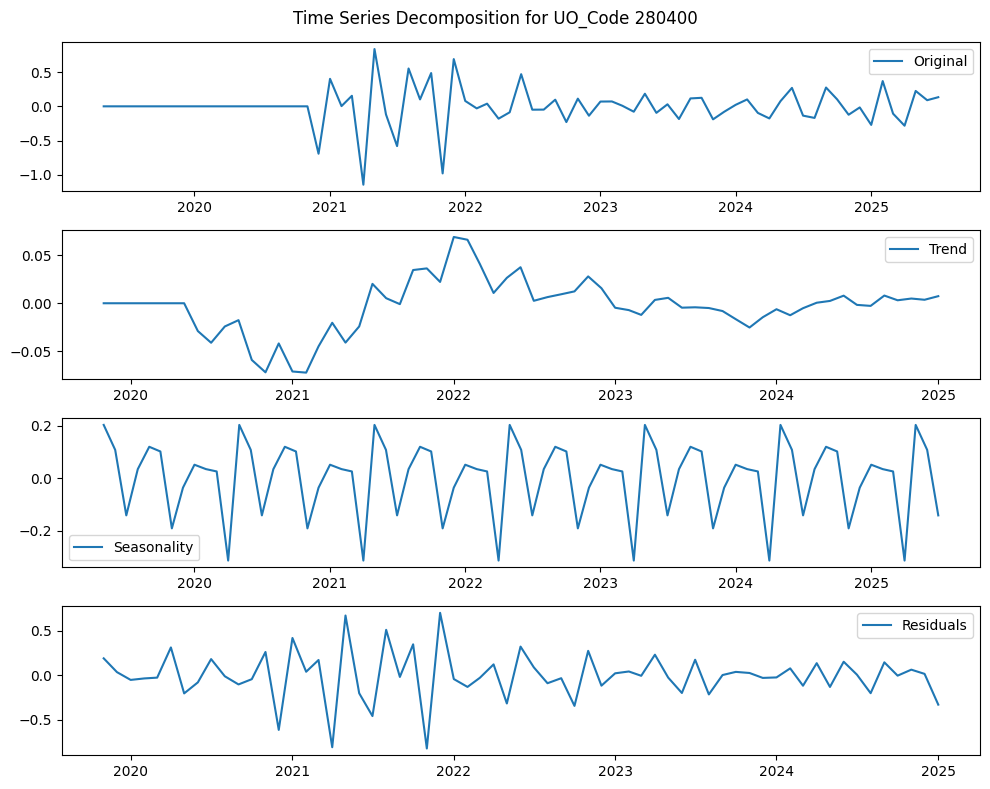


Stationarity Summary (Yes = Stationary, No = Non-Stationary):
       Original  Log Seasonal_Diff Log_First_Diff
150100      Yes  Yes            No            Yes
361900       No   No            No            Yes
100200       No   No            No            Yes
271500      Yes  Yes           Yes            Yes
240800      Yes  Yes            No            Yes
106006      Yes  Yes            No             No
360701      Yes  Yes           Yes            Yes
240100      Yes  Yes            No            Yes
311500       No   No           Yes            Yes
280400       No   No            No            Yes


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

def test_stationarity(timeseries, window=12, cutoff=0.05, show_plot=True):
    rolmean = timeseries.rolling(window).mean()
    rolstd = timeseries.rolling(window).std()

    if show_plot:
        plt.figure(figsize=(10, 4))
        plt.plot(timeseries, color='blue', label='Original')
        plt.plot(rolmean, color='red', label='Rolling Mean')
        plt.plot(rolstd, color='black', label='Rolling Std')
        plt.legend(loc='best')
        plt.title('Rolling Mean & Standard Deviation')
        plt.tight_layout()
        plt.show()

    dftest = adfuller(timeseries.dropna(), autolag='AIC', maxlag=20)
    result = {
        'Test Statistic': dftest[0],
        'p-value': dftest[1],
        '#Lags Used': dftest[2],
        'Number of Observations Used': dftest[3],
        'Stationary': 'Yes' if dftest[1] < cutoff else 'No'
    }
    return result

# Store results for top 10 UO_Codes
final_results = {}

# Replace this with your actual top 10 UO codes
top_10_uo_codes = list(uo_dfs.keys())[:10]

for code in top_10_uo_codes:
    df = uo_dfs[code].groupby(['Report_Date'], as_index=False)['Settlement_Ratio'].mean()
    df.set_index('Report_Date', inplace=True)
    df.sort_index(inplace=True)

    results_dict = {}

    # 1. Original Series
    results_dict['Original'] = test_stationarity(df['Settlement_Ratio'], show_plot=False)

    # 2. Log Transformation
    df['log_outs'] = np.log(df['Settlement_Ratio'].replace(0, np.nan))
    results_dict['Log'] = test_stationarity(df['log_outs'], show_plot=False)

    # 3. Seasonal Differencing (lag=3)
    df['Outs_diff'] = df['Settlement_Ratio'] - df['Settlement_Ratio'].shift(3)
    results_dict['Seasonal_Diff'] = test_stationarity(df['Outs_diff'], show_plot=False)

    # 4. First-order Differencing on Log
    df['out_diff1'] = df['log_outs'].diff()
    df.dropna(subset=['out_diff1'], inplace=True)
    results_dict['Log_First_Diff'] = test_stationarity(df['out_diff1'], show_plot=False)

    # 5. Seasonal Decomposition
    try:
        decomposition = seasonal_decompose(df['out_diff1'], model='additive')
        trend = decomposition.trend
        seasonal = decomposition.seasonal
        residual = decomposition.resid

        # Plot decomposition
        plt.figure(figsize=(10, 8))
        plt.subplot(411)
        plt.plot(df['out_diff1'], label='Original')
        plt.legend(loc='best')
        plt.subplot(412)
        plt.plot(trend, label='Trend')
        plt.legend(loc='best')
        plt.subplot(413)
        plt.plot(seasonal, label='Seasonality')
        plt.legend(loc='best')
        plt.subplot(414)
        plt.plot(residual, label='Residuals')
        plt.legend(loc='best')
        plt.suptitle(f'Time Series Decomposition for UO_Code {code}')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Decomposition failed for {code}: {e}")

    final_results[code] = results_dict

# Summary Table
stationarity_summary = pd.DataFrame({
    code: {step: res['Stationary'] for step, res in results.items()}
    for code, results in final_results.items()
}).T

print("\nStationarity Summary (Yes = Stationary, No = Non-Stationary):")
print(stationarity_summary)

### Top 10 Most Frequent RO_Codes Data Analysis

In [23]:
df.head(3)

,Report_Date,IC_Name,RO_Name,RO_Code,DO_Name,DO_Code,UO_Name,UO_Code,Servicing_Branch,Client_Type,PolicySubType,ActiveLives,No_Of_Policies,Inception_Premium,endors_premium,PolicyRunday,Beg_OS_Cashless_Claims,Beg_OS_NonCashless_Claims,Beg_OS_Cashless_LodgeAmt,Beg_OS_NonCashless_LodgeAmt,Beg_OS_Cashless_LiabAmt,Beg_OS_NonCashless_LiabAmt,Paid_Cashless_Claims,Paid_NonCashless_Claims,Paid_Cashless_LodgeAmt,Paid_NonCashless_LodgeAmt,Paid_Cashless_LiabAmt,Paid_NonCashless_LiabAmt,CRS_Cashless_Claims,CRS_NonCashless_Claims,CRS_Cashless_LodgeAmt,CRS_NonCashless_LodgeAmt,CRS_Cashless_LiabAmt,CRS_NonCashless_LiabAmt,End_OS_Cashless_Claims,End_OS_NonCashless_Claims,End_OS_Cashless_LodgeAmt,End_OS_NonCashless_LodgeAmt,End_OS_Cashless_LiabAmt,End_OS_NonCashless_LiabAmt,Total_crs_claims,Total_paid_claims,Total_End_OS_claims,Total_Beg_OS_claims,Total_Rep_Claims,Settled_Claims,Settlement_Ratio
0,2019-04-01,national insurance company limited,ahmedabad ro,300500,junagadh do,3005,junagadh do,300500,ahmedabad,non-corporate,national mediclaim,22,7,56869.0,0.0,126,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,189000.0,470601.0,126000.0,375348.0,0.0,1.0,0.0,63756.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0.0,0.0,6.0,6.0,100.0
1,2019-04-01,national insurance company limited,ahmedabad ro,300500,junagadh do,3005,junagadh do,300500,ahmedabad,non-corporate,national parivar mediclaim,2,1,41368.0,0.0,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,33493.0,0.0,29697.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,100.0
2,2019-04-01,national insurance company limited,ahmedabad ro,300500,junagadh do,3005,junagadh do,300500,ahmedabad,non-corporate,parivar mediclaim,22,4,39688.0,0.0,38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,17298.0,0.0,16748.0,0.0,0.0,0.0,133625.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0,2.0,100.0


In [26]:
# most frequent top 10 uo_names 
top_10_ro_codes = df['RO_Code'].value_counts(ascending=False).head(10).index.tolist()

RO_SR_df = df[['Report_Date','RO_Name','RO_Code','Total_crs_claims','Total_paid_claims','Total_End_OS_claims',
'Total_Beg_OS_claims','Total_Rep_Claims','Settled_Claims','Settlement_Ratio']]

# Create a dictionary to hold the 10 DataFrames
ro_dfs = {}
# Loop through each top UO_Name and create a separate DataFrame
for code in top_10_ro_codes:
    ro_dfs[code] = RO_SR_df[RO_SR_df['RO_Code'] == code].copy()
    ro_dfs[code] = ro_dfs[code].groupby(['Report_Date'], as_index=False)['Settlement_Ratio'].mean()
    
print(top_10_ro_codes)

['150100', '361900', '100200', '271500', '240800', '106006', '360701', '240100', '311500', '280400']


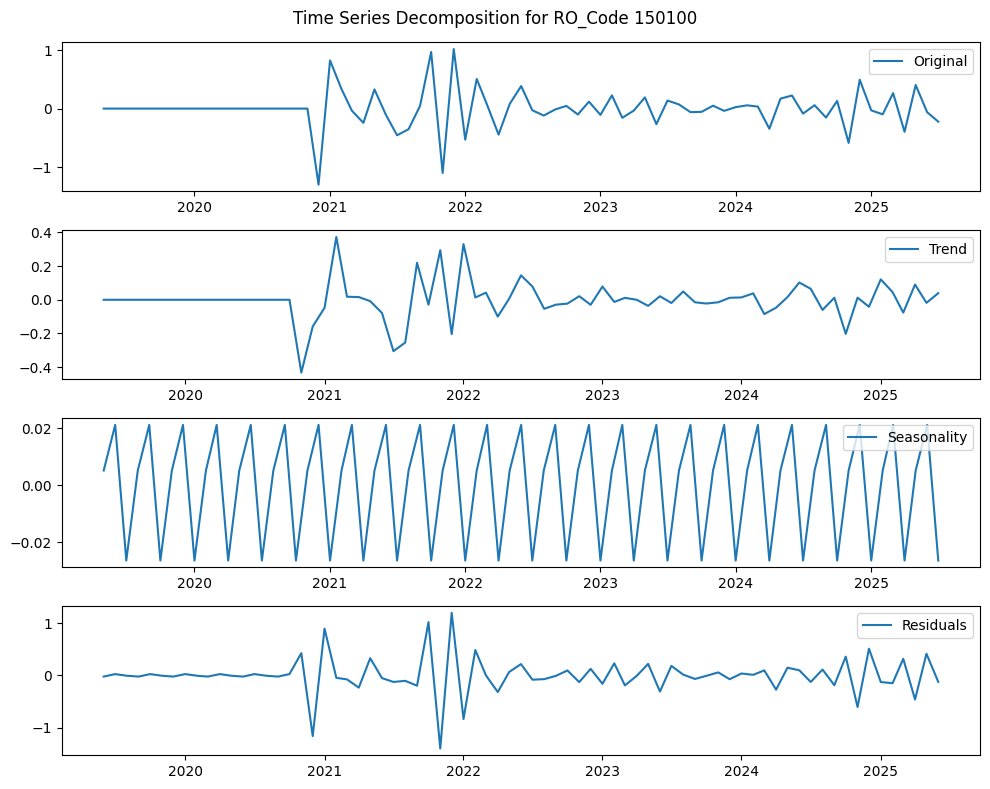

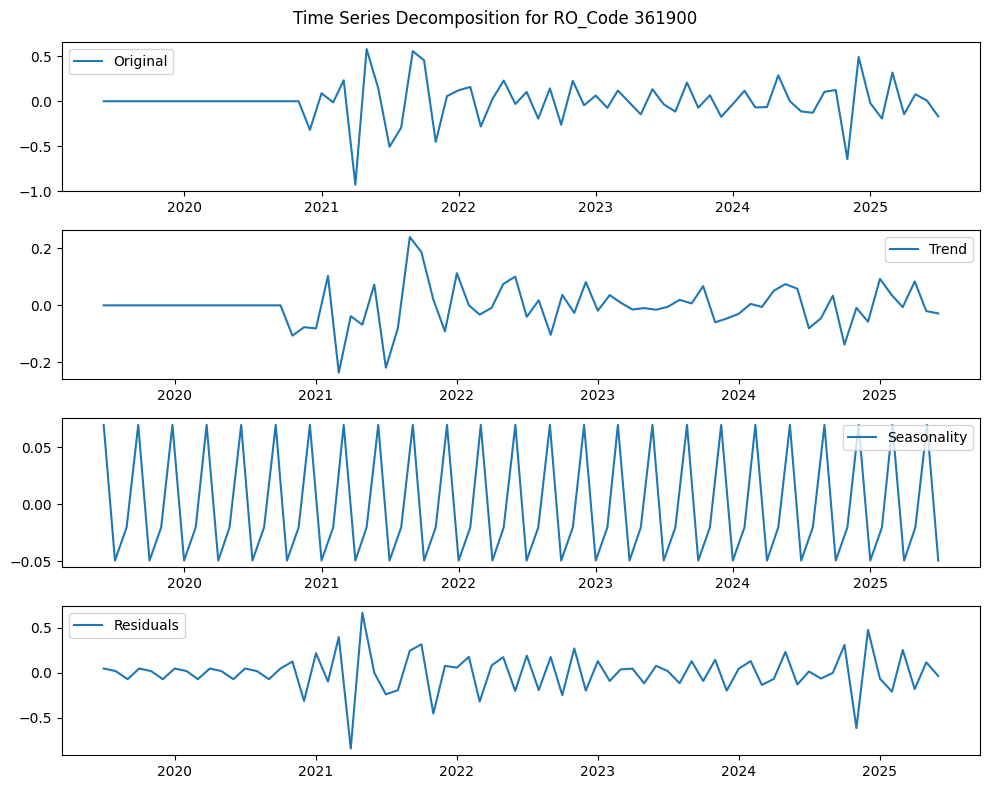

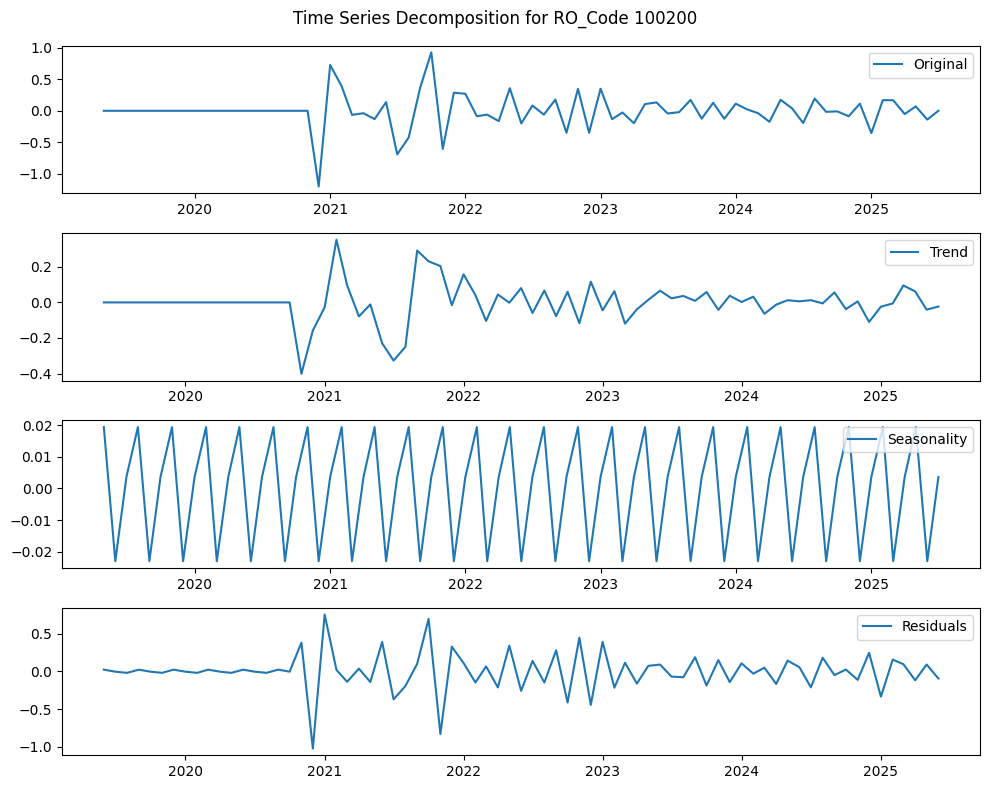

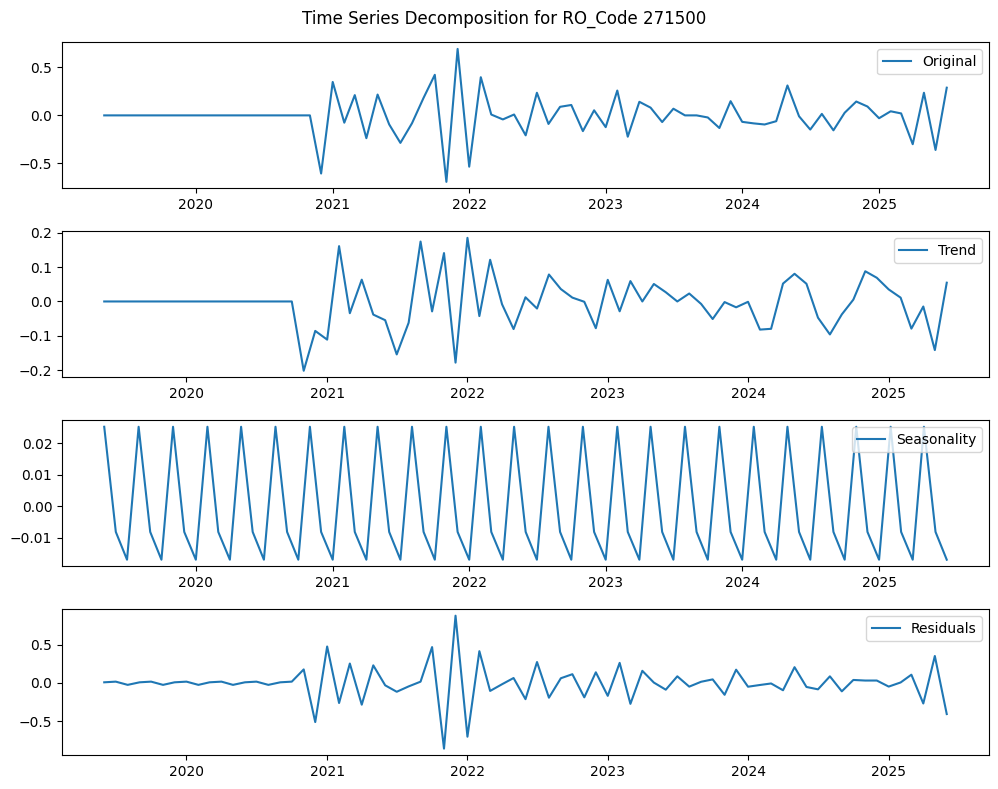

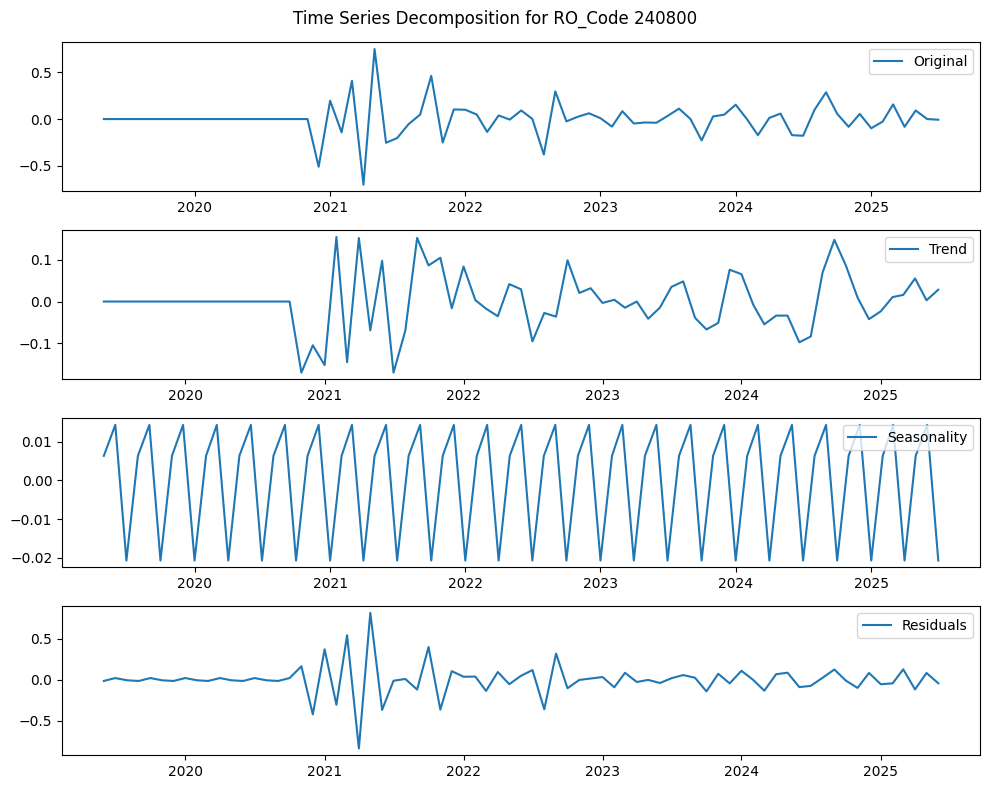

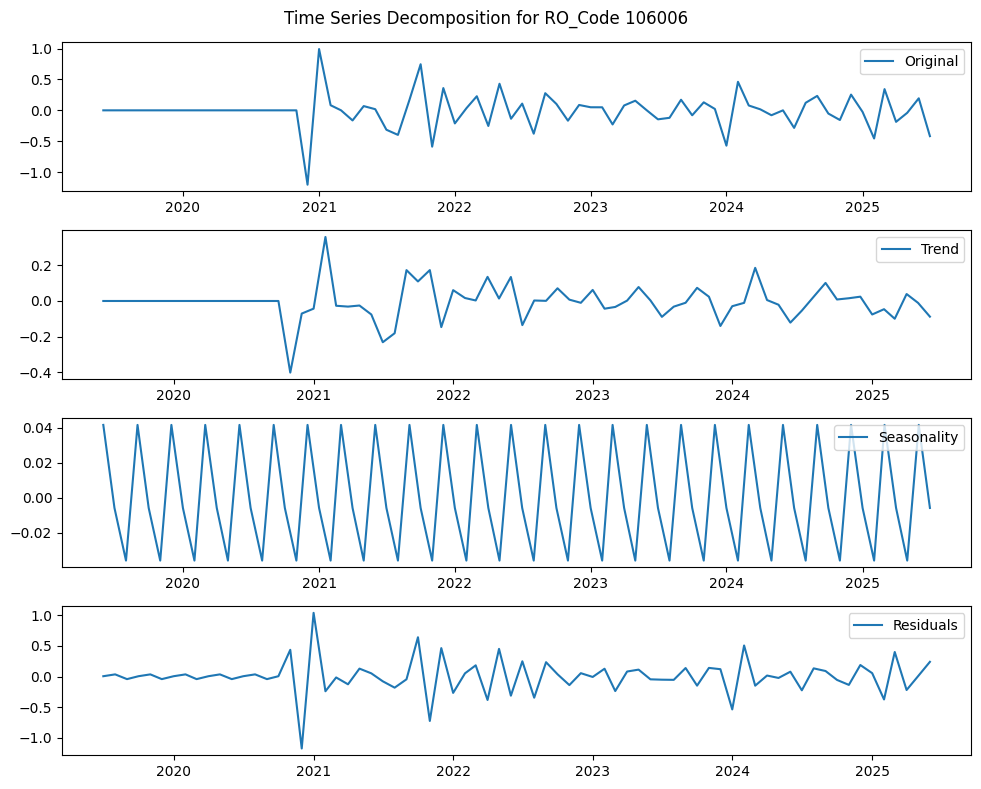

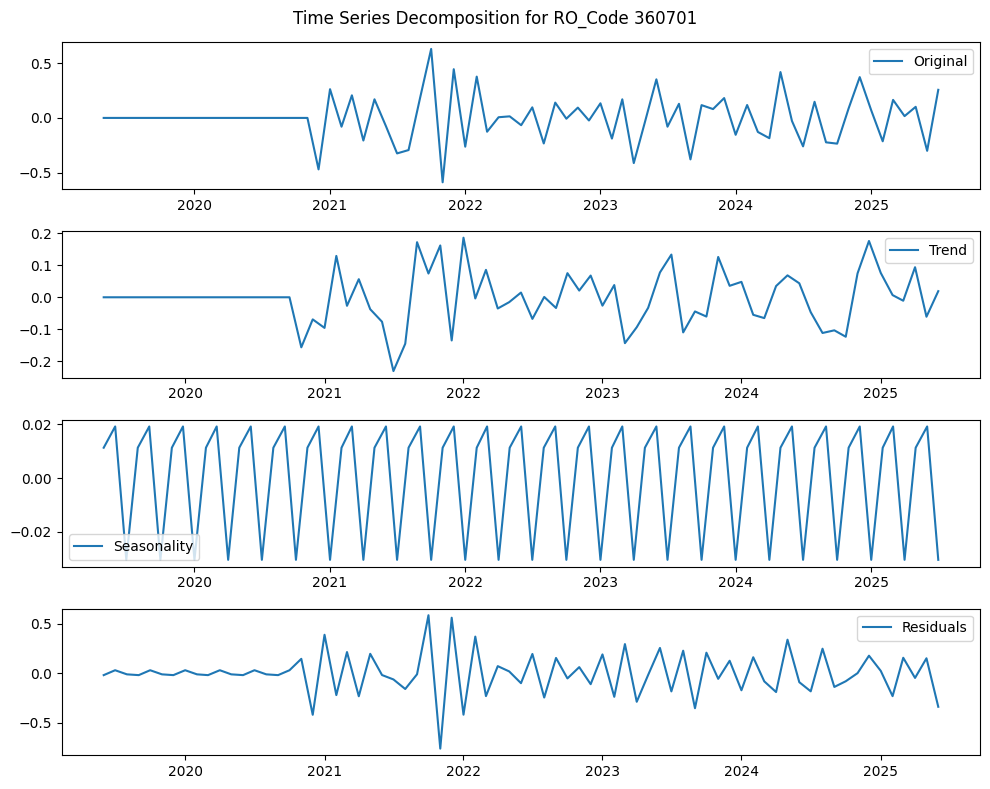

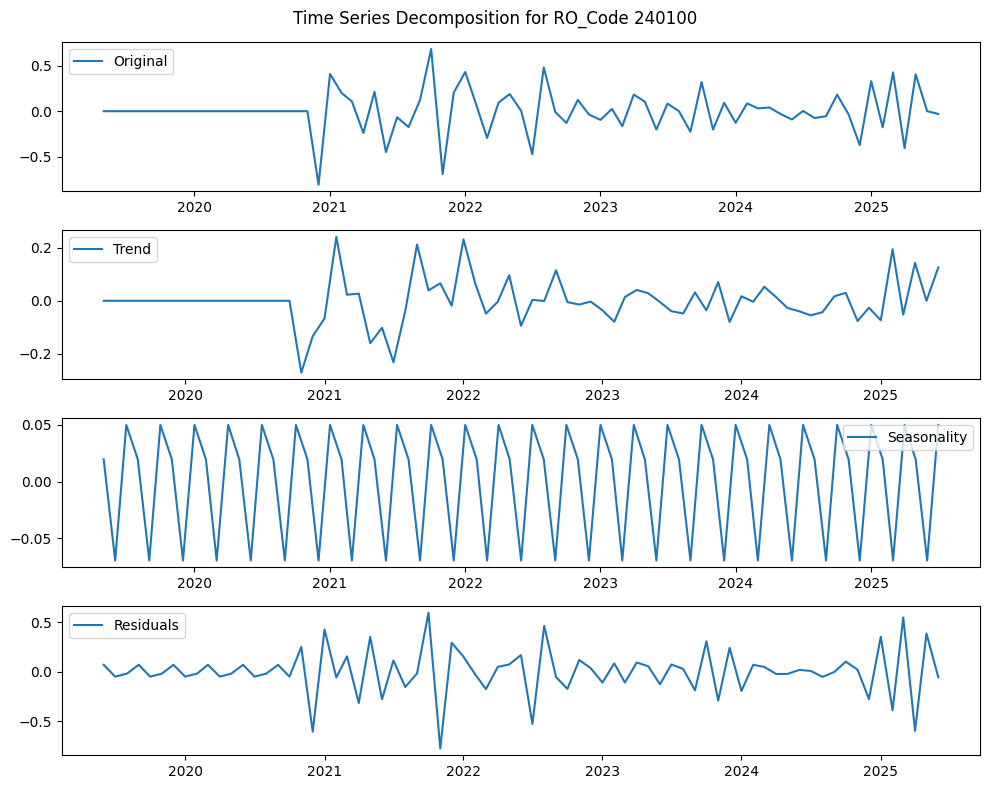

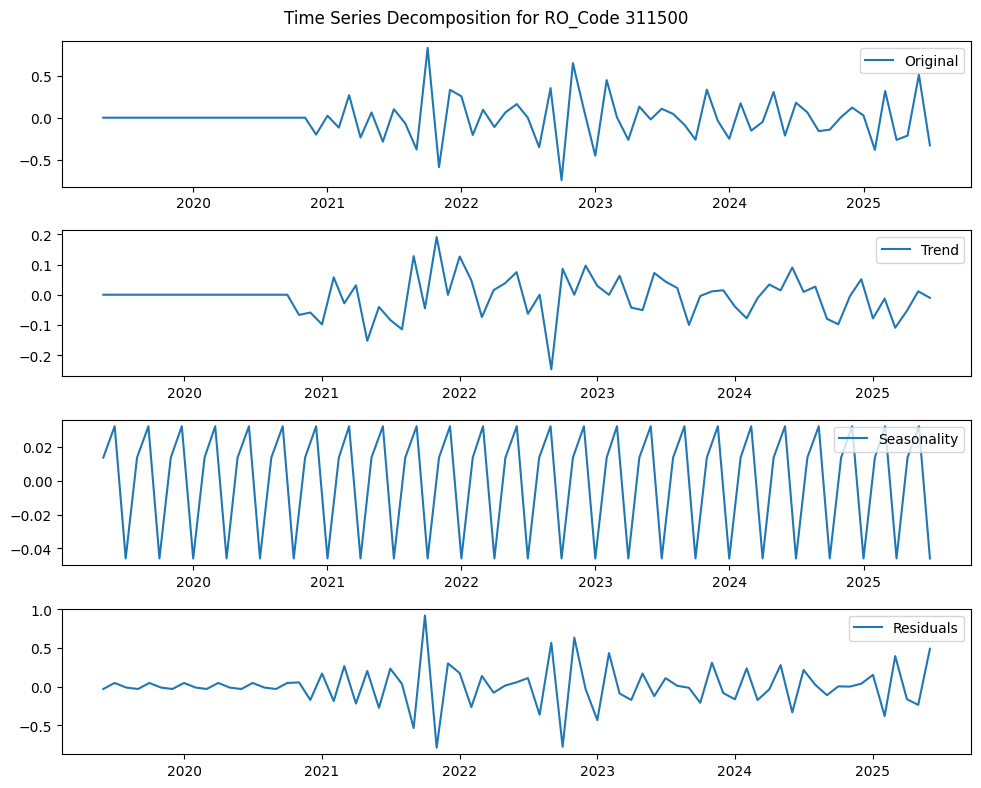

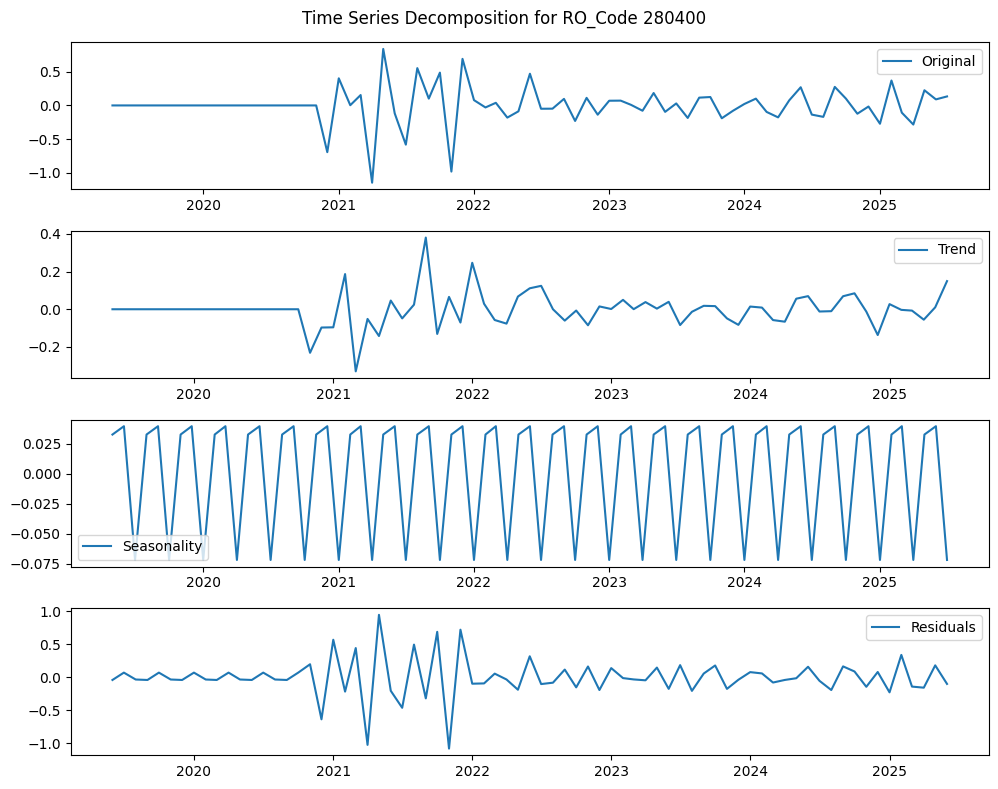


Stationarity Summary (Yes = Stationary, No = Non-Stationary):
       Original  Log Seasonal_Diff Log_First_Diff
150100      Yes  Yes            No            Yes
361900       No   No            No            Yes
100200       No   No            No            Yes
271500      Yes  Yes           Yes            Yes
240800      Yes  Yes            No            Yes
106006      Yes  Yes            No             No
360701      Yes  Yes           Yes            Yes
240100      Yes  Yes            No            Yes
311500       No   No           Yes            Yes
280400       No   No            No            Yes


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

def test_stationarity(timeseries, window=12, cutoff=0.05, show_plot=True):
    ts_clean = timeseries.dropna()

    # Safety checks
    if len(ts_clean) < 5:
        return {'Error': 'Not enough data after cleaning'}
    if ts_clean.max() == ts_clean.min():
        return {'Error': 'Series is constant'}

    rolmean = ts_clean.rolling(window).mean()
    rolstd = ts_clean.rolling(window).std()

    if show_plot:
        plt.figure(figsize=(10, 4))
        plt.plot(ts_clean, color='blue', label='Original')
        plt.plot(rolmean, color='red', label='Rolling Mean')
        plt.plot(rolstd, color='black', label='Rolling Std')
        plt.legend(loc='best')
        plt.title('Rolling Mean & Standard Deviation')
        plt.tight_layout()
        plt.show()

    dftest = adfuller(ts_clean, autolag='AIC', maxlag=20)
    return {
        'Test Statistic': dftest[0],
        'p-value': dftest[1],
        '#Lags Used': dftest[2],
        'Number of Observations Used': dftest[3],
        'Stationary': 'Yes' if dftest[1] < cutoff else 'No'
    }

# Store results for top 10 UO_Codes
final_results = {}

top_10_ro_codes = list(ro_dfs.keys())[:10]  # Replace with actual RO codes

for code in top_10_ro_codes:
    df1 = ro_dfs[code].groupby(['Report_Date'], as_index=False)['Settlement_Ratio'].mean()
    df1.set_index('Report_Date', inplace=True)
    df1.sort_index(inplace=True)

    results_dict = {}

    # 1. Original Series
    results_dict['Original'] = test_stationarity(df1['Settlement_Ratio'], show_plot=False)

    # 2. Log Transformation
    df1['log_outs'] = np.log(df1['Settlement_Ratio'].replace(0, np.nan))
    results_dict['Log'] = test_stationarity(df1['log_outs'], show_plot=False)

    # 3. Seasonal Differencing (lag=3) - FIXED
    df1['Outs_diff'] = df1['Settlement_Ratio'] - df1['Settlement_Ratio'].shift(3)
    results_dict['Seasonal_Diff'] = test_stationarity(df1['Outs_diff'], show_plot=False)

    # 4. First-order Differencing on Log
    df1['out_diff1'] = df1['log_outs'].diff()
    results_dict['Log_First_Diff'] = test_stationarity(df1['out_diff1'], show_plot=False)

    # 5. Seasonal Decomposition
    try:
        decomposition = seasonal_decompose(df1['out_diff1'].dropna(), model='additive', period=3)
        trend = decomposition.trend
        seasonal = decomposition.seasonal
        residual = decomposition.resid

        # Plot decomposition
        plt.figure(figsize=(10, 8))
        plt.subplot(411)
        plt.plot(df1['out_diff1'], label='Original')
        plt.legend(loc='best')
        plt.subplot(412)
        plt.plot(trend, label='Trend')
        plt.legend(loc='best')
        plt.subplot(413)
        plt.plot(seasonal, label='Seasonality')
        plt.legend(loc='best')
        plt.subplot(414)
        plt.plot(residual, label='Residuals')
        plt.legend(loc='best')
        plt.suptitle(f'Time Series Decomposition for RO_Code {code}')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Decomposition failed for {code}: {e}")

    final_results[code] = results_dict

# Summary Table
stationarity_summary = pd.DataFrame({
    code: {step: res.get('Stationary', res.get('Error')) for step, res in results.items()}
    for code, results in final_results.items()
}).T

print("\nStationarity Summary (Yes = Stationary, No = Non-Stationary):")
print(stationarity_summary)

In [11]:
a = {}
for i in range(1,10):
    a[str(i)] = i


In [12]:
a

{'1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9}

In [13]:
for i in a.keys():
    print(a[i])

1
2
3
4
5
6
7
8
9


In [ ]:
for 